In [79]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [80]:
np.random.seed(42)

In [81]:
df = pd.read_csv("Salary_dataset.csv")
df = df.drop(columns=["Unnamed: 0"])

In [102]:
print(df)

    YearsExperience    Salary
0               1.2   39344.0
1               1.4   46206.0
2               1.6   37732.0
3               2.1   43526.0
4               2.3   39892.0
5               3.0   56643.0
6               3.1   60151.0
7               3.3   54446.0
8               3.3   64446.0
9               3.8   57190.0
10              4.0   63219.0
11              4.1   55795.0
12              4.1   56958.0
13              4.2   57082.0
14              4.6   61112.0
15              5.0   67939.0
16              5.2   66030.0
17              5.4   83089.0
18              6.0   81364.0
19              6.1   93941.0
20              6.9   91739.0
21              7.2   98274.0
22              8.0  101303.0
23              8.3  113813.0
24              8.8  109432.0
25              9.1  105583.0
26              9.6  116970.0
27              9.7  112636.0
28             10.4  122392.0
29             10.6  121873.0


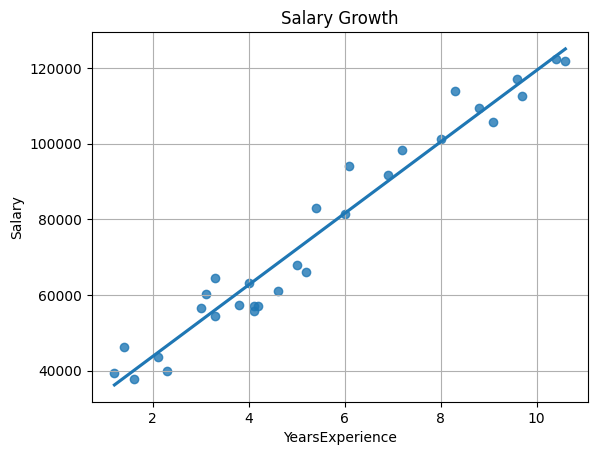

In [83]:
sns.regplot(x="YearsExperience", y="Salary", data=df, ci=None)
plt.title("Salary Growth")
plt.grid()
plt.show()

In [84]:
X = df[["YearsExperience"]]
y = df["Salary"]

In [85]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [86]:
X_train = sm.add_constant(X_train)
X_test = sm.add_constant(X_test)

In [87]:
model = sm.OLS(y_train, X_train).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                 Salary   R-squared:                       0.965
Model:                            OLS   Adj. R-squared:                  0.963
Method:                 Least Squares   F-statistic:                     598.4
Date:                Mon, 02 Mar 2026   Prob (F-statistic):           1.91e-17
Time:                        21:00:38   Log-Likelihood:                -239.44
No. Observations:                  24   AIC:                             482.9
Df Residuals:                      22   BIC:                             485.2
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const            2.438e+04   2319.691     

In [88]:
y_pred = model.predict(X_test)

In [89]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

MAE: 6286.453830757743
RMSE: 7059.043621901508
R2: 0.9024461774180498


In [90]:
X_future = pd.DataFrame({
    "YearsExperience": np.arange(10.8, 12.2, 0.2)
})

X_future = sm.add_constant(X_future)

y_future = model.predict(X_future)

future_df = X_future.copy()
future_df["PredictedSalary"] = y_future

future_df

,const,YearsExperience,PredictedSalary
0,1.0,10.8,126157.406968
1,1.0,11.0,128042.170033
2,1.0,11.2,129926.933097
3,1.0,11.4,131811.696162
4,1.0,11.6,133696.459227
5,1.0,11.8,135581.222291
6,1.0,12.0,137465.985356


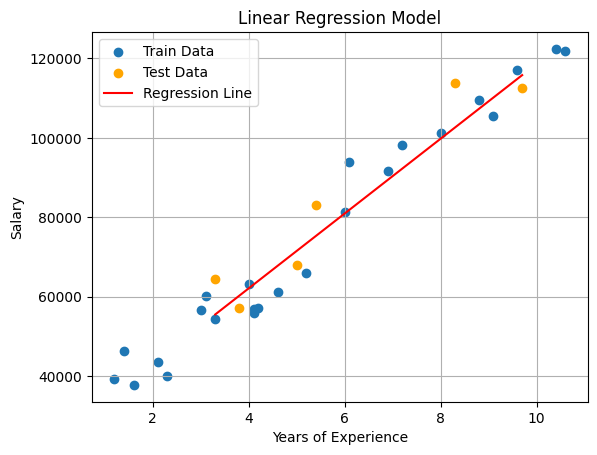

In [99]:
plt.scatter(X_train["YearsExperience"], y_train, label="Train Data")
plt.scatter(X_test["YearsExperience"], y_test, label="Test Data", color="orange")

X_plot = X_test.sort_values("YearsExperience")
y_plot = model.predict(X_plot)

plt.plot(X_plot["YearsExperience"], y_plot, color="red", label="Regression Line")

plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.title("Linear Regression Model")
plt.legend()
plt.grid()
plt.show()

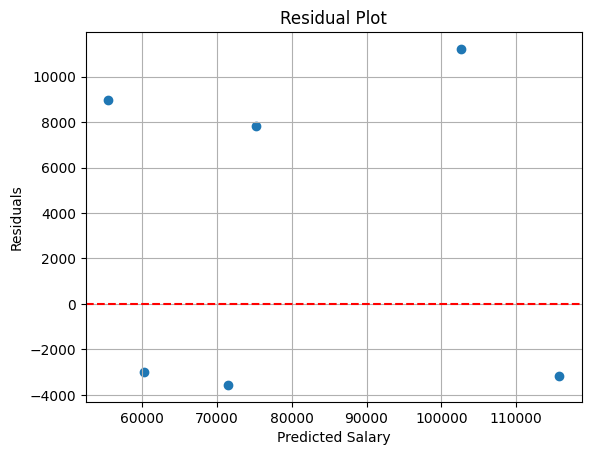

In [95]:
residuals = y_test - y_pred

plt.scatter(y_pred, residuals)
plt.axhline(0, color="red", linestyle="--")

plt.xlabel("Predicted Salary")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.grid()
plt.show()

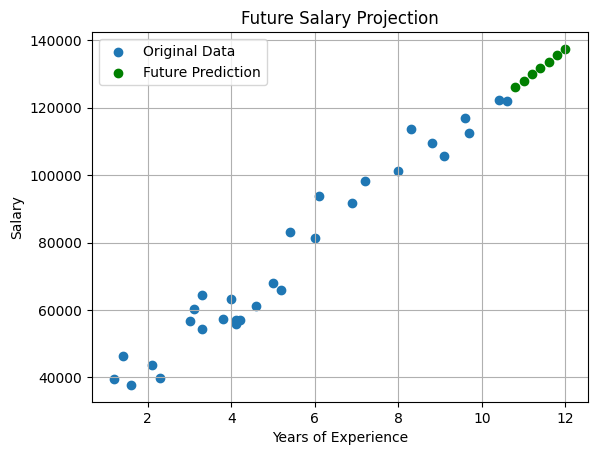

In [97]:
plt.scatter(df["YearsExperience"], df["Salary"], label="Original Data")

plt.scatter(X_future["YearsExperience"], y_future, color="green", label="Future Prediction")

plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.title("Future Salary Projection")
plt.legend()
plt.grid()
plt.show()

1. Problem Statement

. Predict salary based on years of experience using linear regression.

2. Dataset Description

. Feature: YearsExperience

. Target: Salary

. Observations: 30 records

3. Model Used

. Ordinary Least Squares (OLS) Linear Regression.

4. Model Performance

. MAE: ~6286

. RMSE: ~7059

. R²: ~0.90

5. Interpretation:

. The model explains approximately 90% of the variance in salary.

6. Interpretation of Coefficient

. From model summary: Coefficient ≈ 9423

. Meaning for every additional year of experience, salary increases by approximately ₹9423 on average.

7. Conclusion

. The model performs well for a single-feature regression and provides reasonable salary predictions. However, salary may also depend on other factors not included in this dataset.